## Lagrange orbits - Second order system with hard constrains

---



*   The original formulation of the problem yielded a periodic solution with period $T = 4$. To mitigate the effects of saturation in the $tanh$ activation function, the governing equations and initial conditions were rescaled so that the resulting period became $T = 0.5$. Consequently, the network inputs remained largely within the near-linear operating region of the activation function, facilitating more effective training of the PINN.

*   The applied scaling transformation preserves the governing equations and only changes the scales of the dependent variables. Consequently, the rescaled problem is dynamically equivalent to the original system while being more suitable for neural network training.



In [1]:
import os
os.environ["DDE_BACKEND"] = "tensorflow"

In [ ]:
!pip install deepxde

In [ ]:
!pip install tensorflow tf_keras matplotlib numpy scipy

#Training


*   hardware - TPU  (or CPU if not available)
*   Important hyperparameters: loss_weights , learning rate
*   Two learning rates, $10^{-4}$ and $10^{-5}$, were investigated. The smaller learning rate resulted in improved fitting accuracy and lower training loss. However, inspection of the training and test loss curves indicates that, after approximately 70,000 epochs, further training does not improve the test loss. This behavior suggests the onset of overfitting, whereby the network continues to reduce the training error without achieving better generalization performance. Furthermore, after approximately 300,000 training epochs, the test loss begins to increase while the training loss continues to decrease. This behavior suggests a deterioration in generalization performance. It also suggests that improved training strategies, such as adaptive sampling, regularization techniques, or an increased number of collocation points, may be required to further enhance the solution accuracy.








In [4]:
import deepxde as dde
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from numpy.linalg import norm

dde.config.set_default_float("float64")
seed=137
np.random.seed(seed)
tf.random.set_seed(seed)
dde.config.set_random_seed(seed)

# Constants
scale=2  #scale factor  -- time/scale**3 -- space/scale**2 -- velocities*scale
G = 1.0
m = [1.0, 1.0, 1.0]
endTime = 4/scale**3

num_domain = 64
num_boundary = 12
num_test = 100

layer_size = [1] + [64]*3 + [6]  # 6 outputs for positions only
activation = "tanh"
initializer = "Glorot uniform"
loss_weights = [1]*4 +[1]*2   #all weights equal..
iterations = 100000
learning_rate = 1e-4
eps = 1e-9

# --------------------------------------------------
# Initial conditions
# --------------------------------------------------
omega=0.3
# positions
x1_0, y1_0 = -1.0/scale**2, 0.0/scale**2
x2_0, y2_0 =  1.0/scale**2, 0.0/scale**2
x3_0, y3_0 =  0.0/scale**2, np.sqrt(3)/scale**2

# velocities
vx1_0, vy1_0 = (-np.sqrt(3)/3)*omega*scale, 1*omega*scale
vx2_0, vy2_0 = (-np.sqrt(3)/3)*omega*scale, -1*omega*scale
vx3_0, vy3_0 = (2*np.sqrt(3)/3)*omega*scale, 0*scale

y0 = np.array([x1_0, y1_0, x2_0, y2_0,x3_0, y3_0], dtype=np.float64)
v0 = np.array([vx1_0, vy1_0, vx2_0, vy2_0,vx3_0, vy3_0], dtype=np.float64)

y0_tf = tf.constant(y0)
v0_tf = tf.constant(v0)


# ============================================================
# Residual for second-order ODEs
# ============================================================
def three_body_ode_second(t, y):
    # r: [batch_size, 6] -> x1,y1,x2,y2,x3,y3
    x1, y1, x2, y2, x3, y3 = [y[:, i:i+1] for i in range(6)]

    # pairwise distances
    r12 = tf.sqrt((x1 - x2)**2 + (y1 - y2)**2 +eps)
    r13 = tf.sqrt((x1 - x3)**2 + (y1 - y3)**2 +eps)
    r23 = tf.sqrt((x2 - x3)**2 + (y2 - y3)**2 +eps)

    r12_3 = (r12)**3
    r13_3 = (r13)**3
    r23_3 = (r23)**3

    # accelerations
    ax1 = G*( m[1]*(x2 - x1)/r12_3 + m[2]*(x3 - x1)/r13_3 )
    ay1 = G*( m[1]*(y2 - y1)/r12_3 + m[2]*(y3 - y1)/r13_3 )
    ax2 = G*( m[0]*(x1 - x2)/r12_3 + m[2]*(x3 - x2)/r23_3 )
    ay2 = G*( m[0]*(y1 - y2)/r12_3 + m[2]*(y3 - y2)/r23_3 )
    ax3 = G*( m[0]*(x1 - x3)/r13_3 + m[1]*(x2 - x3)/r23_3 )
    ay3 = G*( m[0]*(y1 - y3)/r13_3 + m[1]*(y2 - y3)/r23_3 )

    # second derivatives
    x1_tt = dde.grad.hessian(y, t, component=0, i=0, j=0)
    y1_tt = dde.grad.hessian(y, t, component=1, i=0, j=0)
    x2_tt = dde.grad.hessian(y, t, component=2, i=0, j=0)
    y2_tt = dde.grad.hessian(y, t, component=3, i=0, j=0)
    x3_tt = dde.grad.hessian(y, t, component=4, i=0, j=0)
    y3_tt = dde.grad.hessian(y, t, component=5, i=0, j=0)

    return [
        x1_tt - ax1,
        y1_tt - ay1,
        x2_tt - ax2,
        y2_tt - ay2,
        x3_tt - ax3,
        y3_tt - ay3
    ]

# --------------------------------------------------
# Geometry
# --------------------------------------------------
geom = dde.geometry.TimeDomain(0, endTime)


data = dde.data.PDE(
    geom,
    three_body_ode_second,
    [],
    num_domain=num_domain,
    num_boundary=num_boundary,
    num_test=num_test
)

# ============================================================
# Network and hard constraints
# ============================================================
net = dde.nn.FNN(layer_size, activation, initializer)

# --------------------------------------------------
# HARD CONSTRAINTS (position + velocity)
# --------------------------------------------------
def output_transform(t, y):
    """
    Enforces:
    y(0) = y0
    y'(0) = v0
    """
    return y0_tf + v0_tf * t + (t**2) * y

net.apply_output_transform(output_transform)

model = dde.Model(data, net)


#model.compile(
#    optimizer=tf.keras.optimizers.AdamW(1e-4, weight_decay=1e-5,loss_weights=loss_weights),
#    loss="MSE",
#)
model.compile("adam", lr=learning_rate, loss_weights=loss_weights, loss="MSE")
losshistory, train_state = model.train(iterations=iterations)

model.compile("L-BFGS")  # no learning rate needed
losshistory, train_state = model.train()

# ============================================================
#   SAVE AND LOAD MODEL
# ============================================================
## Load the saved weights
# first - Build the network with dummy predict
#_ = model.predict(np.array([[0.0]]))
#model.restore("Euler_1nd_order_system-2000.weights.h5")
model.save("Lagrange_L-BFGS_2nd_order_system")



/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Set the default float type to float64
Compiling model...
'compile' took 0.008855 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
0         [2.82e+01, 2.67e+00, 1.42e+01, 1.53e+01, 5.97e+00, 2.24e+01]    [2.88e+01, 1.91e+00, 1.30e+01, 1.64e+01, 6.47e+00, 2.15e+01]    []  
1000      [9.83e+00, 1.30e+00, 5.87e-01, 1.03e+01, 5.88e+00, 4.95e+00]    [9.71e+00, 9.97e-01, 5.27e-01, 9.86e+00, 5.42e+00, 4.80e+00]    []  
2000      [8.46e-01, 2.16e+00, 6.73e-01, 1.79e+00, 2.49e+00, 1.96e-01]    [8.90e-01, 2.49e+00, 7.83e-01, 1.93e+00, 2.73e+00, 1.81e-01]    []  
3000      [3.72e-01, 1.15e+00, 4.95e-01, 8.83e-01, 1.25e+00, 1.13e-01]    [3.58e-01, 1.34e+00, 5.67e-01, 9.44e-01, 1.39e+00, 1.06e-01]    []  
4000      [1.92e-01, 8.70e-01, 4.26e-01, 5.85e-01, 8.80e-01, 7.16e-02]    [1.75e-01, 1.02e+00, 5.00e-01, 6.37e-01, 9.98e-01, 7.37e-02]    []  
5000      [1.41e-01, 6.63e-01, 3

'Lagrange_L-BFGS_2nd_order_system-115000.weights.h5'

#Plots and Results

Saving loss history to /content/loss.dat ...
Saving training data to /content/train.dat ...
Saving test data to /content/test.dat ...


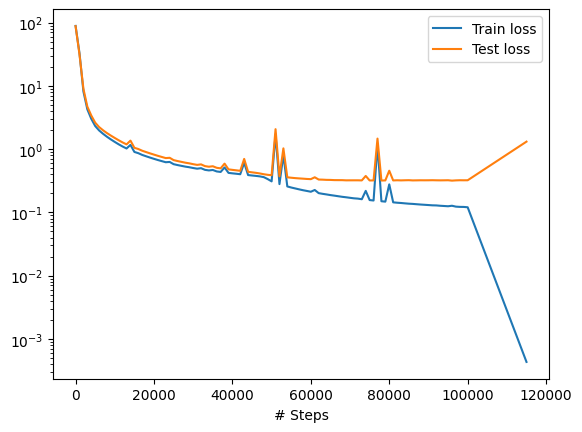

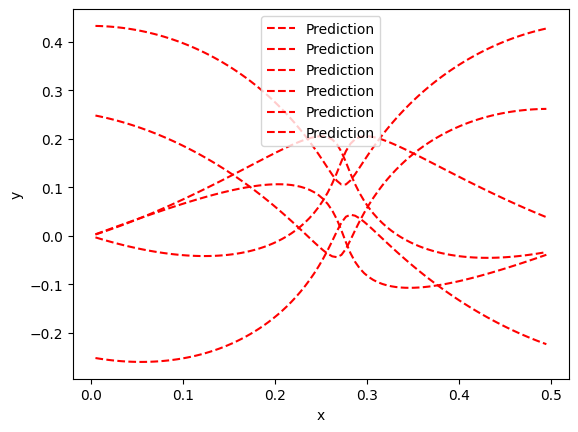

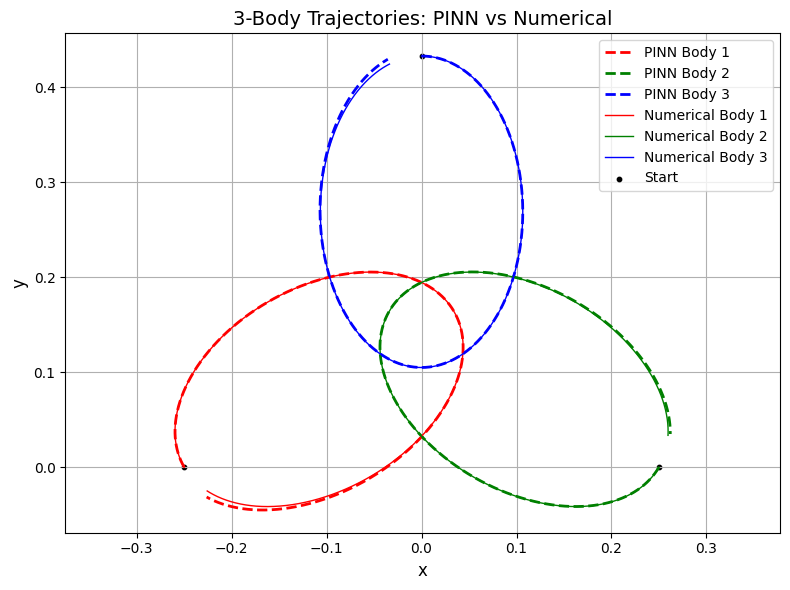


--- L2 Relative Errors ---
Body 1 x error: 8.98e-04
Body 1 y error: 2.15e-02
Body 2 x error: 3.77e-03
Body 2 y error: 6.45e-03
Body 3 x error: 7.98e-03
Body 3 y error: 4.80e-03
(103, 6)


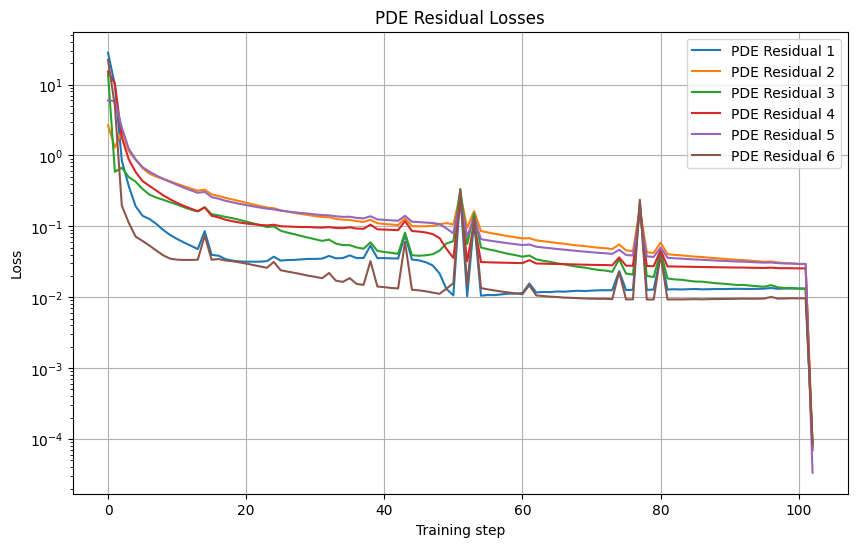

In [5]:

dde.saveplot(losshistory, train_state, issave=True, isplot=True)
# ============================================================
# PINN Predictions
# ============================================================
t_test = np.linspace(0, endTime, 5000)[:, None]
y_pred = model.predict(t_test)

x1, y1 = y_pred[:, 0], y_pred[:, 1]
x2, y2 = y_pred[:, 2], y_pred[:, 3]
x3, y3 = y_pred[:, 4], y_pred[:, 5]

# ============================================================
# Numerical Solution via SciPy
# ============================================================
def three_body_numeric(t, y, G=1.0, m=(1.0, 1.0, 1.0)):
    x1, y1, vx1, vy1, x2, y2, vx2, vy2, x3, y3, vx3, vy3 = y

    r12 = np.sqrt((x1 - x2)**2 + (y1 - y2)**2 +eps)
    r13 = np.sqrt((x1 - x3)**2 + (y1 - y3)**2 +eps)
    r23 = np.sqrt((x2 - x3)**2 + (y2 - y3)**2 +eps)

    ax1 = G * (m[1]*(x2 - x1)/r12**3 + m[2]*(x3 - x1)/r13**3)
    ay1 = G * (m[1]*(y2 - y1)/r12**3 + m[2]*(y3 - y1)/r13**3)
    ax2 = G * (m[0]*(x1 - x2)/r12**3 + m[2]*(x3 - x2)/r23**3)
    ay2 = G * (m[0]*(y1 - y2)/r12**3 + m[2]*(y3 - y2)/r23**3)
    ax3 = G * (m[0]*(x1 - x3)/r13**3 + m[1]*(x2 - x3)/r23**3)
    ay3 = G * (m[0]*(y1 - y3)/r13**3 + m[1]*(y2 - y3)/r23**3)

    return [vx1, vy1, ax1, ay1,
            vx2, vy2, ax2, ay2,
            vx3, vy3, ax3, ay3]

t_span = (0, endTime)
t_eval = np.linspace(0, endTime, 5000)

y0_full = np.array([
    x1_0, y1_0, vx1_0, vy1_0,
    x2_0, y2_0, vx2_0, vy2_0,
    x3_0, y3_0, vx3_0, vy3_0
])

sol = solve_ivp(three_body_numeric, t_span, y0_full, t_eval=t_eval, rtol=1e-10, atol=1e-12)

x1_n, y1_n = sol.y[0], sol.y[1]
x2_n, y2_n = sol.y[4], sol.y[5]
x3_n, y3_n = sol.y[8], sol.y[9]

# ============================================================
# Compare and Plot Results
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(x1, y1, 'r--', lw=2, label="PINN Body 1")
plt.plot(x2, y2, 'g--', lw=2, label="PINN Body 2")
plt.plot(x3, y3, 'b--', lw=2, label="PINN Body 3")

plt.plot(x1_n, y1_n, 'r-', lw=1, label="Numerical Body 1")
plt.plot(x2_n, y2_n, 'g-', lw=1, label="Numerical Body 2")
plt.plot(x3_n, y3_n, 'b-', lw=1, label="Numerical Body 3")

plt.scatter([x1[0], x2[0], x3[0]],
            [y1[0], y2[0], y3[0]],
            color='k', marker='o', s=10, label='Start')

plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("3-Body Trajectories: PINN vs Numerical", fontsize=14)
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()

# ============================================================
# Optional: Compute relative L2 errors
# ============================================================
interp_x1 = interp1d(t_eval, x1_n, kind='cubic')
interp_y1 = interp1d(t_eval, y1_n, kind='cubic')
interp_x2 = interp1d(t_eval, x2_n, kind='cubic')
interp_y2 = interp1d(t_eval, y2_n, kind='cubic')
interp_x3 = interp1d(t_eval, x3_n, kind='cubic')
interp_y3 = interp1d(t_eval, y3_n, kind='cubic')

x1_ref = norm(x1 - interp_x1(t_test[:,0])) / norm(interp_x1(t_test[:,0]))
y1_ref = norm(y1 - interp_y1(t_test[:,0])) / norm(interp_y1(t_test[:,0]))
x2_ref = norm(x2 - interp_x2(t_test[:,0])) / norm(interp_x2(t_test[:,0]))
y2_ref = norm(y2 - interp_y2(t_test[:,0])) / norm(interp_y2(t_test[:,0]))
x3_ref = norm(x3 - interp_x3(t_test[:,0])) / norm(interp_x3(t_test[:,0]))
y3_ref = norm(y3 - interp_y3(t_test[:,0])) / norm(interp_y3(t_test[:,0]))

print("\n--- L2 Relative Errors ---")
print(f"Body 1 x error: {x1_ref:.2e}")
print(f"Body 1 y error: {y1_ref:.2e}")
print(f"Body 2 x error: {x2_ref:.2e}")
print(f"Body 2 y error: {y2_ref:.2e}")
print(f"Body 3 x error: {x3_ref:.2e}")
print(f"Body 3 y error: {y3_ref:.2e}")



#============================ history losses per pfe res =================================
losses = np.array(losshistory.loss_train)
print(losses.shape)

#dde.utils.plot_loss_history(losshistory)


pde_losses = losses[:, 1:13]

plt.figure(figsize=(10, 6))

for i in range(6):
    plt.semilogy(losses[:, i], label=f"PDE Residual {i+1}")

plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("PDE Residual Losses")
plt.legend()
plt.grid(True)
plt.show()

STATISTICS

In [6]:
# ============================================================
# STATISTICS
# ============================================================


print("\n")
print("="*60)
print("STATISTICS")
print("="*60)

# ============================================================
# PINN velocities from automatic differentiation
# ============================================================

t_tf = tf.convert_to_tensor(t_test, dtype=tf.float64)

with tf.GradientTape() as tape:
    tape.watch(t_tf)
    y_pred_tf = model.net(t_tf)

dy_dt = tape.batch_jacobian(y_pred_tf, t_tf)

# remove singleton dimension
dy_dt = dy_dt[:, :, 0].numpy()

# PINN positions
y_pred = y_pred_tf.numpy()

x1, y1 = y_pred[:,0], y_pred[:,1]
x2, y2 = y_pred[:,2], y_pred[:,3]
x3, y3 = y_pred[:,4], y_pred[:,5]

# PINN velocities
vx1, vy1 = dy_dt[:,0], dy_dt[:,1]
vx2, vy2 = dy_dt[:,2], dy_dt[:,3]
vx3, vy3 = dy_dt[:,4], dy_dt[:,5]

# ============================================================
# Numerical solution
# ============================================================

x1_n  = sol.y[0]
y1_n  = sol.y[1]
vx1_n = sol.y[2]
vy1_n = sol.y[3]

x2_n  = sol.y[4]
y2_n  = sol.y[5]
vx2_n = sol.y[6]
vy2_n = sol.y[7]

x3_n  = sol.y[8]
y3_n  = sol.y[9]
vx3_n = sol.y[10]
vy3_n = sol.y[11]

# ============================================================
# TRAIN / TEST LOSS
# ============================================================

train_losses = np.array(losshistory.loss_train)
test_losses  = np.array(losshistory.loss_test)

final_train_loss = np.sum(train_losses[-1])
final_test_loss  = np.sum(test_losses[-1])

LPDE = final_train_loss     # hard constraints
LDATA = 0.0

print(f"Final Training Loss : {final_train_loss:.2e}")
print(f"Final Test Loss     : {final_test_loss:.2e}")
print(f"PDE Residual Loss   : {LPDE:.2e}")
print(f"Data Loss           : {LDATA:.2e}")

# ============================================================
# 2. POSITION ERRORS - RMSE
# ============================================================

err1 = np.sqrt((x1 - x1_n)**2 + (y1 - y1_n)**2)
err2 = np.sqrt((x2 - x2_n)**2 + (y2 - y2_n)**2)
err3 = np.sqrt((x3 - x3_n)**2 + (y3 - y3_n)**2)

rmse1 = np.sqrt(np.mean(err1**2))
rmse2 = np.sqrt(np.mean(err2**2))
rmse3 = np.sqrt(np.mean(err3**2))

RMSE = np.sqrt(np.mean(
    np.concatenate([
        err1**2,
        err2**2,
        err3**2
    ])
))

print("\nPosition RMSE")
print("-----------------------------")
print(f"Body 1 : {rmse1:.2e}")
print(f"Body 2 : {rmse2:.2e}")
print(f"Body 3 : {rmse3:.2e}")
print(f"Global : {RMSE:.2e}")

print("\nMaximum Position Error")
print("-----------------------------")
print(f"Body 1 : {np.max(err1):.2e}")
print(f"Body 2 : {np.max(err2):.2e}")
print(f"Body 3 : {np.max(err3):.2e}")

max_pos_error = max(
    np.max(err1),
    np.max(err2),
    np.max(err3)
)
print(f"Global Max Position error : {max_pos_error:.2e}")

# ============================================================
# 3. ENERGY
# ============================================================



def total_energy(x1,y1,vx1,vy1,
                 x2,y2,vx2,vy2,
                 x3,y3,vx3,vy3,
                 G=1.0,
                 m=(1.0,1.0,1.0),
                 eps=0.0):

    KE = (
        0.5*m[0]*(vx1**2+vy1**2)
        +0.5*m[1]*(vx2**2+vy2**2)
        +0.5*m[2]*(vx3**2+vy3**2)
    )

    r12 = np.sqrt((x1-x2)**2+(y1-y2)**2+eps)
    r13 = np.sqrt((x1-x3)**2+(y1-y3)**2+eps)
    r23 = np.sqrt((x2-x3)**2+(y2-y3)**2+eps)

    PE = (
        -G*m[0]*m[1]/r12
        -G*m[0]*m[2]/r13
        -G*m[1]*m[2]/r23
    )

    return KE + PE


E = total_energy(
    x1,y1,vx1,vy1,
    x2,y2,vx2,vy2,
    x3,y3,vx3,vy3,
    G,m,eps
)

E0 = E[0]

DE_E0 = np.max(np.abs(E-E0))/abs(E0)

print("\nEnergy Conservation")
print("-----------------------------")
print(f"PINN ΔE/E0 : {DE_E0:.2e}")

E_num = total_energy(
    x1_n, y1_n, vx1_n, vy1_n,
    x2_n, y2_n, vx2_n, vy2_n,
    x3_n, y3_n, vx3_n, vy3_n,
    G, m, eps
)

E0_num = E_num[0]

DE_E0_num = np.max(np.abs(E_num-E0_num))/abs(E0_num)


print("-----------------------------")
print(f"Numerical ΔE/E0 : {DE_E0_num:.2e}")

# ============================================================
# 4. LINEAR MOMENTUM DRIFT
# ============================================================

Px = m[0]*vx1 + m[1]*vx2 + m[2]*vx3
Py = m[0]*vy1 + m[1]*vy2 + m[2]*vy3

DeltaP = np.max(
    np.sqrt(
        (Px - Px[0])**2 +
        (Py - Py[0])**2
    )
)

print("\nLinear Momentum")
print("-----------------------------")
print(f"PINN Max Momentum Drift : {DeltaP:.2e}")

Px_n = m[0]*vx1_n + m[1]*vx2_n + m[2]*vx3_n
Py_n = m[0]*vy1_n + m[1]*vy2_n + m[2]*vy3_n

DeltaP_n = np.max(
    np.sqrt(
        (Px_n - Px_n[0])**2 +
        (Py_n - Py_n[0])**2
    )
)


print("-----------------------------")
print(f"Numerical Max Momentum Drift : {DeltaP_n:.2e}")


# ============================================================
# 5. ANGULAR MOMENTUM
# ============================================================

L = (
      m[0]*(x1*vy1-y1*vx1)
    + m[1]*(x2*vy2-y2*vx2)
    + m[2]*(x3*vy3-y3*vx3)
)

L0 = L[0]

DL_L0 = np.max(np.abs(L-L0))/max(abs(L0),1e-15)

print("\nAngular Momentum Conservation")
print("-----------------------------")
print(f"ΔL/L0 : {DL_L0:.2e}")


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("="*60)
print("SUMMARY")
print("="*60)

print(f"Final Training Loss               : {final_train_loss:.2e}")
print(f"Final Test Loss                   : {final_test_loss:.2e}")
print(f"PDE Residual Loss                 : {LPDE:.2e}")
print(f"Data Loss                         : {LDATA:.2e}")
print(f"Global Max Position error         : {max_pos_error:.2e}")
print(f"Position RMSE                     : {RMSE:.2e}")
print(f"PINN ΔE/E0                        : {DE_E0:.2e}")
print(f"Numerical ΔE/E0                   : {DE_E0_num:.2e}")
print(f"PINN Max Momentum Drift ΔP        : {DeltaP:.2e}")
print(f"Numerical Max Momentum Drift ΔP   : {DeltaP_n:.2e}")
print(f"ΔL/L0                             : {DL_L0:.2e}")



STATISTICS
Final Training Loss : 4.33e-04
Final Test Loss     : 1.31e+00
PDE Residual Loss   : 4.33e-04
Data Loss           : 0.00e+00

Position RMSE
-----------------------------
Body 1 : 2.17e-03
Body 2 : 9.34e-04
Body 3 : 1.73e-03
Global : 1.69e-03

Maximum Position Error
-----------------------------
Body 1 : 6.40e-03
Body 2 : 2.75e-03
Body 3 : 5.38e-03
Global Max Position error : 6.40e-03

Energy Conservation
-----------------------------
PINN ΔE/E0 : 3.31e-02
-----------------------------
Numerical ΔE/E0 : 9.48e-10

Linear Momentum
-----------------------------
PINN Max Momentum Drift : 2.69e-03
-----------------------------
Numerical Max Momentum Drift : 4.93e-15

Angular Momentum Conservation
-----------------------------
ΔL/L0 : 3.97e-03


SUMMARY
Final Training Loss               : 4.33e-04
Final Test Loss                   : 1.31e+00
PDE Residual Loss                 : 4.33e-04
Data Loss                         : 0.00e+00
Global Max Position error         : 6.40e-03
Positi

#Extrapolation for two Periods

======================= Extrapolating for 2 Periods ===============================


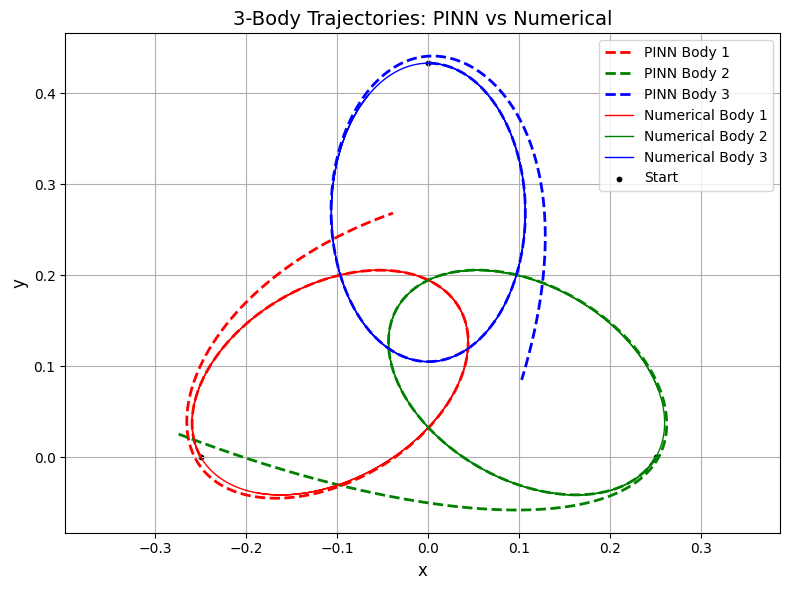


--- L2 Relative Errors ---
Body 1 x error: 3.55e-01
Body 1 y error: 1.02e+00
Body 2 x error: 8.00e-01
Body 2 y error: 8.22e-01
Body 3 x error: 1.14e+00
Body 3 y error: 2.43e-01


In [7]:
#============================ EXTRAPOLATE =================================================
print("===================================================================================")
print("======================= Extrapolating for 2 Periods ===============================")
print("===================================================================================")

exTime=2*endTime

# ============================================================
# PINN Predictions
# ============================================================
t_test = np.linspace(0, exTime, 5000)[:, None]
y_pred = model.predict(t_test)

x1, y1 = y_pred[:, 0], y_pred[:, 1]
x2, y2 = y_pred[:, 2], y_pred[:, 3]
x3, y3 = y_pred[:, 4], y_pred[:, 5]

# ============================================================
# Numerical Solution via SciPy
# ============================================================


t_span = (0, exTime)
t_eval = np.linspace(0, exTime, 5000)

y0_full = np.array([
    x1_0, y1_0, vx1_0, vy1_0,
    x2_0, y2_0, vx2_0, vy2_0,
    x3_0, y3_0, vx3_0, vy3_0
])

sol = solve_ivp(three_body_numeric, t_span, y0_full, t_eval=t_eval, rtol=1e-10, atol=1e-12)

x1_n, y1_n = sol.y[0], sol.y[1]
x2_n, y2_n = sol.y[4], sol.y[5]
x3_n, y3_n = sol.y[8], sol.y[9]

# ============================================================
# Compare and Plot Results
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(x1, y1, 'r--', lw=2, label="PINN Body 1")
plt.plot(x2, y2, 'g--', lw=2, label="PINN Body 2")
plt.plot(x3, y3, 'b--', lw=2, label="PINN Body 3")

plt.plot(x1_n, y1_n, 'r-', lw=1, label="Numerical Body 1")
plt.plot(x2_n, y2_n, 'g-', lw=1, label="Numerical Body 2")
plt.plot(x3_n, y3_n, 'b-', lw=1, label="Numerical Body 3")

plt.scatter([x1[0], x2[0], x3[0]],
            [y1[0], y2[0], y3[0]],
            color='k', marker='o', s=10, label='Start')

plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("3-Body Trajectories: PINN vs Numerical", fontsize=14)
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()

# ============================================================
# Optional: Compute relative L2 errors
# ============================================================
interp_x1 = interp1d(t_eval, x1_n, kind='cubic')
interp_y1 = interp1d(t_eval, y1_n, kind='cubic')
interp_x2 = interp1d(t_eval, x2_n, kind='cubic')
interp_y2 = interp1d(t_eval, y2_n, kind='cubic')
interp_x3 = interp1d(t_eval, x3_n, kind='cubic')
interp_y3 = interp1d(t_eval, y3_n, kind='cubic')

x1_err = norm(x1 - interp_x1(t_test[:,0])) / norm(interp_x1(t_test[:,0]))
y1_err = norm(y1 - interp_y1(t_test[:,0])) / norm(interp_y1(t_test[:,0]))
x2_err = norm(x2 - interp_x2(t_test[:,0])) / norm(interp_x2(t_test[:,0]))
y2_err = norm(y2 - interp_y2(t_test[:,0])) / norm(interp_y2(t_test[:,0]))
x3_err = norm(x3 - interp_x3(t_test[:,0])) / norm(interp_x3(t_test[:,0]))
y3_err = norm(y3 - interp_y3(t_test[:,0])) / norm(interp_y3(t_test[:,0]))

print("\n--- L2 Relative Errors ---")
print(f"Body 1 x error: {x1_err:.2e}")
print(f"Body 1 y error: {y1_err:.2e}")
print(f"Body 2 x error: {x2_err:.2e}")
print(f"Body 2 y error: {y2_err:.2e}")
print(f"Body 3 x error: {x3_err:.2e}")
print(f"Body 3 y error: {y3_err:.2e}")